In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7f167beae510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f167beaf230>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## **Pydantic Schema**

In [9]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the LinkedIn post")
    post: str = Field(description="The content of the linkedIn post")
    refined_post: str = Field(description="The curated LinkedIn post content")

In [11]:
demo_object = graph_schema(topic="The use of AI in QA", post="Write a post on the use of AI in QA industry.", 
refined_post="The AI is changing the QA industry by automating the testing process and improving the accuracy of the tests.")
demo_object.topic, demo_object.post, demo_object.refined_post

('The use of AI in QA',
 'Write a post on the use of AI in QA industry.',
 'The AI is changing the QA industry by automating the testing process and improving the accuracy of the tests.')

## So here we created a schema for our graph which is generating a LinkedIn post on a given topic.

In [22]:
def create_post(state:graph_schema) -> graph_schema:

    state = state.model_dump()  # This is required because pydantic uses state.post, state.topic but we wanted to use it like python dict, hence converted to python dict using model_dump
    topic = state["topic"]

    post = llm.invoke(f"Wrtie a linkedin post about the topic: {topic}").content

    state["post"] = post

    return state

def refine_post(state:graph_schema) -> graph_schema:

    state = state.model_dump()
    post = state["post"]

    refined_post = llm.invoke(f"You are an expert in LinkedIn post curation. Please refine the post: {post} to make it more engaging and interesting for the audience.").content

    state["refined_post"] = refined_post

    return state


## These are nothing but two nodes in our graph. The first node is creating a post and the second one is refining the post.




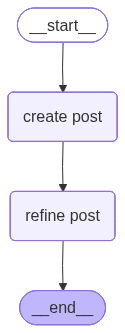

In [23]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display

graph = StateGraph(graph_schema)

# Let's add nodes
graph.add_node("create post",create_post)
graph.add_node("refine post", refine_post)

#Let's add edges
graph.add_edge(START,"create post")
graph.add_edge("create post","refine post")
graph.add_edge("refine post",END)

pydantic_graph = graph.compile()

Image(pydantic_graph.get_graph().draw_mermaid_png())


## Let's invoke the graph now

In [24]:
pydantic_graph.invoke({
    "topic":"Work life balance",
    "post":"",
    "refined_post":""
})

{'topic': 'Work life balance',
 'post': "**Achieving Harmony: The Importance of Work-Life Balance**\n\nAs professionals, we often find ourselves juggling multiple responsibilities, striving to excel in our careers, and navigating the demands of our personal lives. But in the pursuit of success, it's easy to lose sight of what's truly important: our well-being.\n\nAchieving a healthy work-life balance is no longer a luxury, but a necessity. When we prioritize our personal and professional lives, we become more productive, creative, and fulfilled. So, how can we strike a better balance?\n\n **Set clear boundaries**: Establish a clear distinction between your work and personal life by setting boundaries such as specific work hours, a designated workspace, and avoiding work-related activities during personal time.\n\n **Prioritize self-care**: Make time for activities that nourish your mind, body, and soul, such as exercise, meditation, and spending time with loved ones.\n\n **Learn to say

## **Unlike Langchain where the input of one node is output to the other node, here we have subtle difference. The input of the create post node which is node 1 is stored in state which is graph schema here. And then from there it becomes input for node 2 which is refine post in our case.**